## Benchmark Run Script (Reference)

Current Bazel invocation:

```bash
cd /Users/RyanLandvater/Programming_Projects/FastFHIR-benchmarking
./.external/bin/bazelisk run //bench:bench_harness -- --warmup-iterations 3 --iterations 5 --db "host=localhost port=5432 dbname=benchmark user=bench password=bench" --runs 40
```

Database reset helper:

```bash
PGPASSWORD=bench /opt/homebrew/Cellar/libpq/17.4/bin/psql -h localhost -p 5432 -U bench -d benchmark -c "TRUNCATE benchmark_results, benchmark_runs RESTART IDENTITY CASCADE;" && echo "Done"
```

Deprecated old command path removed. Use the benchmark DB command shown above.

# FastFHIR vs JSON-FHIR Benchmark Results

This notebook loads and analyzes benchmark results from the C++ harness.

In [68]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import numpy as np
from pathlib import Path
import os
from sqlalchemy import create_engine, text

# Configuration - read from environment or use benchmark defaults
db_host = os.getenv('POSTGRES_HOST', 'localhost')
db_port = os.getenv('POSTGRES_PORT', '5432')
db_name = os.getenv('POSTGRES_DB', 'benchmark')
db_user = os.getenv('POSTGRES_USER', 'bench')
db_pass = os.getenv('POSTGRES_PASSWORD', 'bench')

results_svg_dir = Path('results/svg')
results_svg_dir.mkdir(parents=True, exist_ok=True)

db_url = f"postgresql+psycopg2://{db_user}:{db_pass}@{db_host}:{db_port}/{db_name}"
print(f"Connecting to {db_user}@{db_host}:{db_port}/{db_name}")
print(f"Saving SVG plots to {results_svg_dir.resolve()}")

def format_speedup_tick(y, _):
    if y <= 0 or not np.isfinite(y):
        return ''
    if y >= 10:
        return f"{y:,.0f}x"
    if y >= 1:
        s = f"{y:.2f}".rstrip('0').rstrip('.')
        return f"{s}x"
    s = f"{y:.3f}".rstrip('0').rstrip('.')
    return f"{s}x"

def format_mb_tick(x, _):
    if x <= 0 or not np.isfinite(x):
        return ''
    if abs(x - round(x)) < 1e-9:
        return f"{int(round(x))} MB"
    return f"{x:g} MB"

Connecting to bench@localhost:5432/benchmark
Saving SVG plots to C:\Users\ryanl\Documents\GitHub\FastFHIR-benchmark\notebooks\results\svg


## Load Results from Database

In [69]:
try:
    engine = create_engine(db_url, pool_pre_ping=True)
    with engine.connect() as conn:
        conn.execute(text("SELECT 1"))
    print("Connected successfully (SQLAlchemy)")
except Exception as e:
    print(f"Connection failed: {e}")
    engine = None

Connected successfully (SQLAlchemy)


## Summary Statistics

In [77]:
if 'engine' in locals() and engine is not None:
    query = """
    WITH latest AS (
        SELECT MAX(run_id) AS run_id
        FROM benchmark_results
    )
    SELECT
        br.id,
        br.run_id,
        br.arm,
        br.stage,
        br.duration_ns,
        br.target_mb,
        br.patients_in_bundle,
        br.created_at
    FROM benchmark_results br
    JOIN latest l ON br.run_id = l.run_id
    ORDER BY br.target_mb, br.arm, br.stage
    """
    
    # Load only the latest run to avoid truncating larger target sizes.
    df = pd.read_sql(query, engine)

    # Normalize stage labels to the canonical test taxonomy.
    # Handles both legacy (stage1_serialize) and short-form (test_1) formats.
    test_name_map = {
        'stage1_serialize': 'test_1_serialize',
        'test_1': 'test_1_serialize',
        'stage2_transport': 'test_2_materialize',
        'stage3_materialize': 'test_2_materialize',
        'test_2': 'test_2_materialize',
        'stage3_query': 'test_3_query',
        'test_3': 'test_3_query',
        'stage4_enrich': 'test_4_enrich',
        'test_4': 'test_4_enrich',
    }
    df['test'] = df['stage'].replace(test_name_map)

    # Keep notebook charts in microseconds while storing raw timings in nanoseconds.
    df['duration_us'] = df['duration_ns'].astype(float) / 1000.0

    # Throughput in records/sec; keep float dtype to avoid object arrays in plotting.
    df['records_per_second'] = np.where(
        df['duration_us'] > 0,
        (df['patients_in_bundle'] * 1_000_000.0) / df['duration_us'],
        np.nan,
    ).astype(float)
    
    # Dynamically detect arms present in the data.
    # Google FHIR is macOS-only and won't appear on Windows runs.
    known_arms = ['fastfhir', 'json_fhir', 'hl7v2', 'google_fhir']
    arms_in_data = sorted(df['arm'].unique())
    plot_arms = [a for a in arms_in_data if a in known_arms]
    missing = [a for a in known_arms if a not in arms_in_data]
    if missing:
        print(f"Note: {', '.join(missing)} arm(s) not found in latest run (expected on macOS only)")

    # Convenience DataFrames for manual inspection when needed.
    df_preview = df.head(20).copy()
    latest_run_id = int(df['run_id'].max()) if len(df) > 0 else None
    latest_run_df = df.copy() if len(df) > 0 else pd.DataFrame()
else:
    df = pd.DataFrame()
    df_preview = pd.DataFrame()
    latest_run_df = pd.DataFrame()
    latest_run_id = None
    plot_arms = []



Note: google_fhir arm(s) not found in latest run (expected on macOS only)


## Summary Statistics

In [71]:
if 'df' in locals() and len(df) > 0:
    summary = df.groupby(['arm', 'test'])['duration_us'].agg(['mean', 'std', 'min', 'max']).round(2)
    arm_totals = df.groupby('arm')['duration_us'].agg(['sum', 'mean', 'count']).round(2)
    
    # Keep optional preview frames ready for manual review.
    summary_preview = summary.reset_index().copy()
    arm_totals_preview = arm_totals.reset_index().copy()
else:
    summary = pd.DataFrame()
    arm_totals = pd.DataFrame()
    summary_preview = pd.DataFrame()
    arm_totals_preview = pd.DataFrame()
summary_preview

,arm,test,mean,std,min,max
0,fastfhir,test_1_serialize,61.47,63.88,7.7,244.9
1,fastfhir,test_2_materialize,0.55,0.28,0.3,2.6
2,fastfhir,test_3_query,1.28,0.85,0.4,4.3
3,fastfhir,test_4_enrich,10.00,5.13,5.6,34.1
4,hl7v2,test_1_serialize,530.66,559.74,43.3,2107.9
5,hl7v2,test_2_materialize,144.07,155.09,11.6,647.8
6,hl7v2,test_3_query,1.69,1.48,0.3,5.4
7,hl7v2,test_4_enrich,39.80,13.48,28.6,92.0
8,json_fhir,test_1_serialize,325.27,339.46,30.8,1167.3
9,json_fhir,test_2_materialize,37.15,38.35,4.8,138.5


## Performance Comparison - Serialization

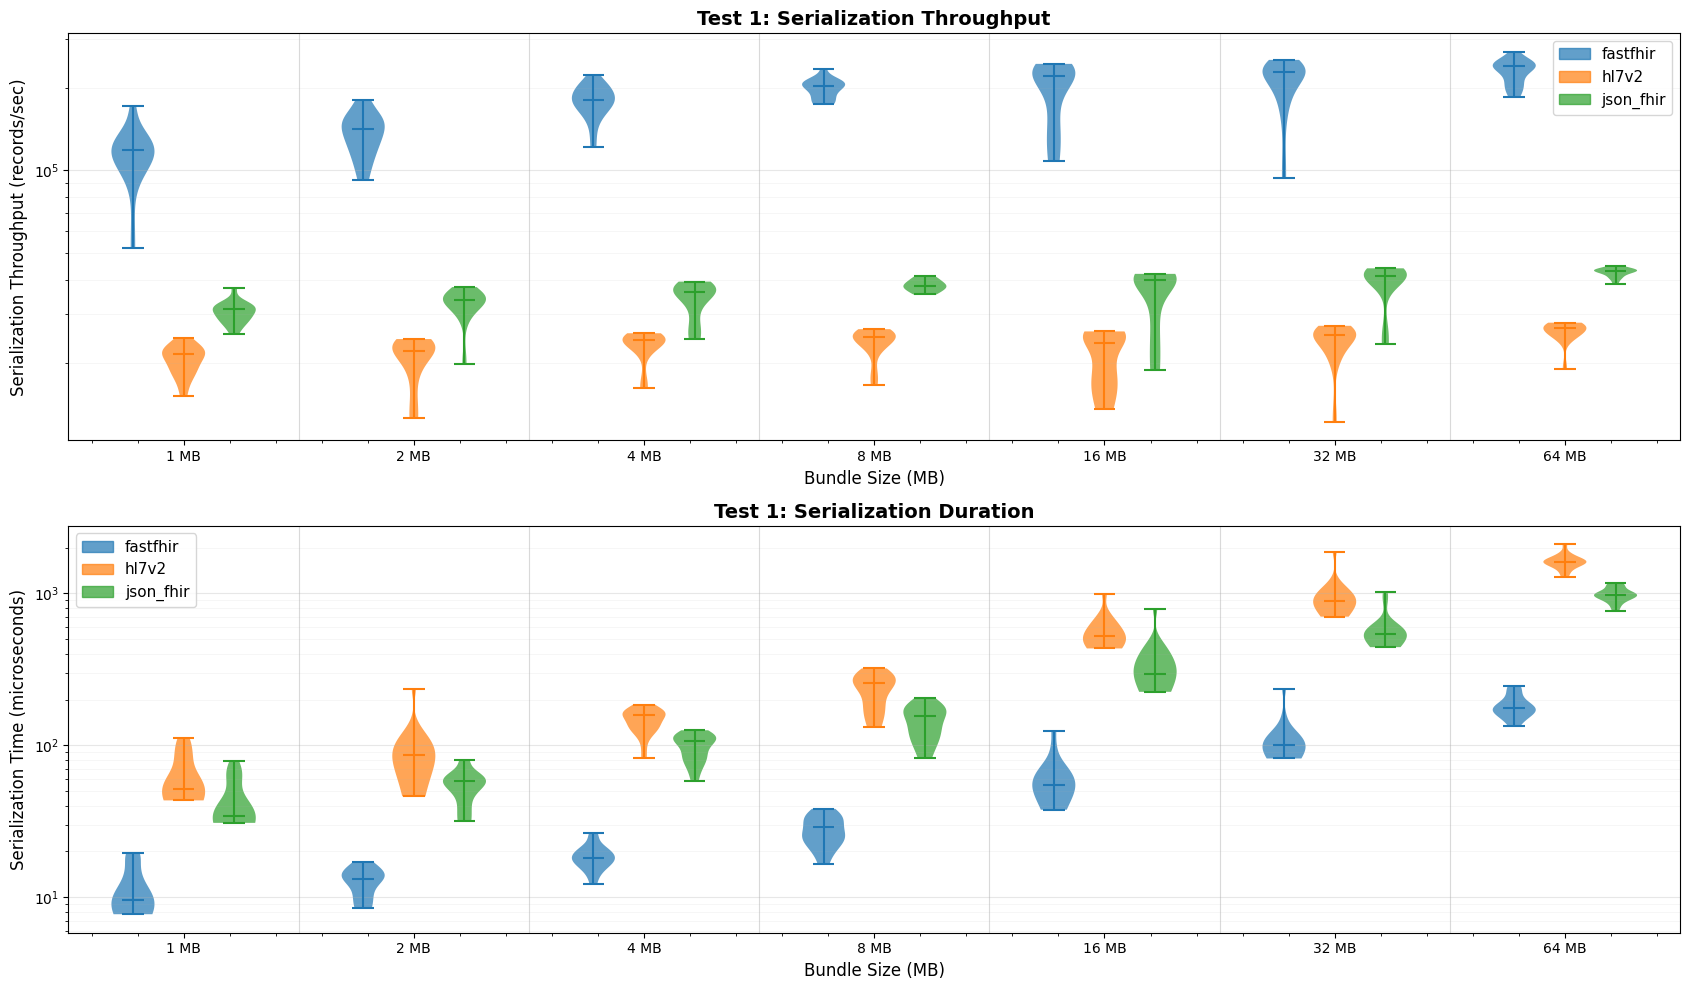

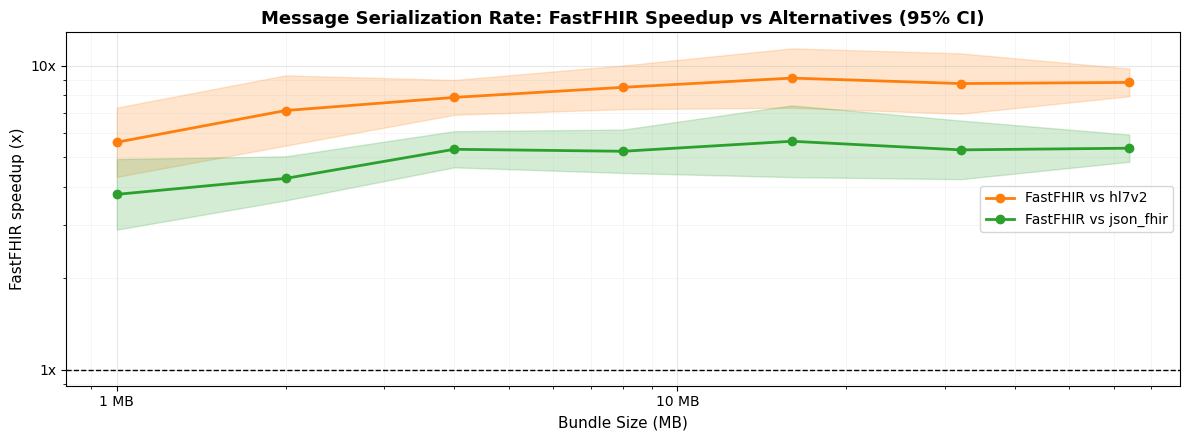

In [78]:
if 'df' in locals() and len(df) > 0:
    use_latest_run_only = True
    source_df = latest_run_df if use_latest_run_only and 'latest_run_df' in locals() and len(latest_run_df) > 0 else df
    test1_data = source_df[source_df['test'] == 'test_1_serialize'].copy()

    if len(test1_data) > 0:
        show_smoke_arms = False
        if not show_smoke_arms:
            test1_data = test1_data[test1_data['arm'].isin(plot_arms)].copy()

        arms = sorted(test1_data['arm'].unique())
        target_mbs = sorted(test1_data['target_mb'].unique())
        n_arms = len(arms)
        n_targets = len(target_mbs)

        colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
        arm_colors = {arm: colors[i] for i, arm in enumerate(arms)}

        # Keep each bin under ~70% of axis width so adjacent bins do not overlap.
        max_cluster_span = 0.70
        width = min(0.22, max_cluster_span / max(n_arms, 1))
        fig, (ax_rps, ax_dur) = plt.subplots(2, 1, figsize=(17, 10))

        # Top plot: Records per second (throughput)
        for ai, arm in enumerate(arms):
            offset = (ai - (n_arms - 1) / 2) * width
            positions = [i + 1 + offset for i in range(n_targets)]
            violin_data = [
                pd.to_numeric(
                    test1_data[(test1_data['arm'] == arm) & (test1_data['target_mb'] == mb)]['records_per_second'],
                    errors='coerce',
                ).replace([np.inf, -np.inf], np.nan).dropna().astype(float).values
                for mb in target_mbs
            ]
            valid = [(pos, d) for pos, d in zip(positions, violin_data) if len(d) >= 2]
            if valid:
                vpos, vdata = zip(*valid)
                parts = ax_rps.violinplot(list(vdata), positions=list(vpos), widths=width * 0.85,
                                      showmedians=True, showextrema=True)
                color = arm_colors[arm]
                for pc in parts['bodies']:
                    pc.set_facecolor(color)
                    pc.set_alpha(0.7)
                for key in ('cmedians', 'cmaxes', 'cmins', 'cbars'):
                    parts[key].set_color(color)
                    parts[key].set_linewidth(1.5)
            ax_rps.fill_between([], [], color=arm_colors[arm], alpha=0.7, label=arm)

        ax_rps.set_xticks(range(1, n_targets + 1))
        ax_rps.set_xticklabels([f'{mb} MB' for mb in target_mbs])
        ax_rps.set_xlim(0.5, n_targets + 0.5)
        for x in range(1, n_targets):
            ax_rps.axvline(x + 0.5, color='0.85', linewidth=0.8, zorder=0)
        ax_rps.set_xlabel('Bundle Size (MB)', fontsize=12)
        ax_rps.set_ylabel('Serialization Throughput (records/sec)', fontsize=12)
        ax_rps.set_title('Test 1: Serialization Throughput', fontsize=14, fontweight='bold')
        ax_rps.legend(fontsize=11)
        ax_rps.grid(True, alpha=0.3, axis='y', which='major')
        ax_rps.set_yscale('log')
        ax_rps.minorticks_on()
        ax_rps.grid(True, alpha=0.12, axis='y', which='minor', linewidth=0.6)

        # Bottom plot: Duration (microseconds)
        for ai, arm in enumerate(arms):
            offset = (ai - (n_arms - 1) / 2) * width
            positions = [i + 1 + offset for i in range(n_targets)]
            violin_data = [
                test1_data[(test1_data['arm'] == arm) & (test1_data['target_mb'] == mb)]['duration_us'].astype(float).values
                for mb in target_mbs
            ]
            valid = [(pos, d) for pos, d in zip(positions, violin_data) if len(d) >= 2]
            if valid:
                vpos, vdata = zip(*valid)
                parts = ax_dur.violinplot(list(vdata), positions=list(vpos), widths=width * 0.85,
                                      showmedians=True, showextrema=True)
                color = arm_colors[arm]
                for pc in parts['bodies']:
                    pc.set_facecolor(color)
                    pc.set_alpha(0.7)
                for key in ('cmedians', 'cmaxes', 'cmins', 'cbars'):
                    parts[key].set_color(color)
                    parts[key].set_linewidth(1.5)
            ax_dur.fill_between([], [], color=arm_colors[arm], alpha=0.7, label=arm)

        ax_dur.set_xticks(range(1, n_targets + 1))
        ax_dur.set_xticklabels([f'{mb} MB' for mb in target_mbs])
        ax_dur.set_xlim(0.5, n_targets + 0.5)
        for x in range(1, n_targets):
            ax_dur.axvline(x + 0.5, color='0.85', linewidth=0.8, zorder=0)
        ax_dur.set_xlabel('Bundle Size (MB)', fontsize=12)
        ax_dur.set_ylabel('Serialization Time (microseconds)', fontsize=12)
        ax_dur.set_title('Test 1: Serialization Duration', fontsize=14, fontweight='bold')
        ax_dur.legend(fontsize=11)
        ax_dur.grid(True, alpha=0.3, axis='y', which='major')
        ax_dur.set_yscale('log')
        ax_dur.minorticks_on()
        ax_dur.grid(True, alpha=0.12, axis='y', which='minor', linewidth=0.6)

        plt.tight_layout()
        fig.savefig(results_svg_dir / 'test1_serialization_violin.svg', format='svg', bbox_inches='tight')
        plt.show()

        # Secondary plot: how many times FastFHIR is faster than each alternative
        speedup_stats = test1_data.groupby(['arm', 'target_mb'])['duration_us'].agg(['mean', 'std', 'count']).reset_index()
        fast_stats = speedup_stats[speedup_stats['arm'] == 'fastfhir'][['target_mb', 'mean', 'std', 'count']].rename(
            columns={'mean': 'fast_mean', 'std': 'fast_std', 'count': 'fast_count'}
        )
        alt_arms = [a for a in arms if a != 'fastfhir']

        if len(fast_stats) > 0 and alt_arms:
            fig_sp, ax_sp = plt.subplots(figsize=(12, 4.5))
            for arm in alt_arms:
                merged = speedup_stats[speedup_stats['arm'] == arm].merge(fast_stats, on='target_mb', how='inner')
                merged = merged[(merged['mean'] > 0) & (merged['fast_mean'] > 0)].copy()
                if len(merged) == 0:
                    continue

                ratio = merged['mean'] / merged['fast_mean']
                lower = ratio.copy()
                upper = ratio.copy()

                safe = (merged['count'] > 1) & (merged['fast_count'] > 1) & merged['std'].notna() & merged['fast_std'].notna() & (merged['std'] > 0) & (merged['fast_std'] > 0)
                if safe.any():
                    se_log = np.sqrt(
                        (merged.loc[safe, 'std'] ** 2) / (merged.loc[safe, 'count'] * (merged.loc[safe, 'mean'] ** 2)) +
                        (merged.loc[safe, 'fast_std'] ** 2) / (merged.loc[safe, 'fast_count'] * (merged.loc[safe, 'fast_mean'] ** 2))
                    )
                    log_ratio = np.log(ratio.loc[safe])
                    lower.loc[safe] = np.exp(log_ratio - 1.96 * se_log)
                    upper.loc[safe] = np.exp(log_ratio + 1.96 * se_log)

                color = arm_colors.get(arm)
                ax_sp.plot(merged['target_mb'], ratio, marker='o', linewidth=2, color=color, label=f'FastFHIR vs {arm}')
                ax_sp.fill_between(merged['target_mb'], lower, upper, color=color, alpha=0.2)

            ax_sp.axhline(1.0, color='black', linestyle='--', linewidth=1)
            ax_sp.set_xticks(target_mbs)
            ax_sp.set_xticklabels([f'{mb} MB' for mb in target_mbs])
            ax_sp.set_xlabel('Bundle Size (MB)', fontsize=11)
            ax_sp.set_ylabel('FastFHIR speedup (x)', fontsize=11)
            ax_sp.set_title('Message Serialization Rate: FastFHIR Speedup vs Alternatives (95% CI)', fontsize=13, fontweight='bold')
            ax_sp.set_yscale('log')
            ax_sp.set_xscale('log')
            ax_sp.xaxis.set_major_formatter(FuncFormatter(format_mb_tick))
            ax_sp.yaxis.set_major_formatter(FuncFormatter(format_speedup_tick))
            ax_sp.minorticks_on()
            ax_sp.grid(True, alpha=0.12, which='minor', linewidth=0.6)
            ax_sp.grid(True, alpha=0.3)
            ax_sp.legend(fontsize=10)
            plt.tight_layout()
            fig_sp.savefig(results_svg_dir / 'test1_serialization_speedup_ci.svg', format='svg', bbox_inches='tight')
            plt.show()
    else:
        print('No test 1 serialization data found')

## Performance Comparison - Materialization

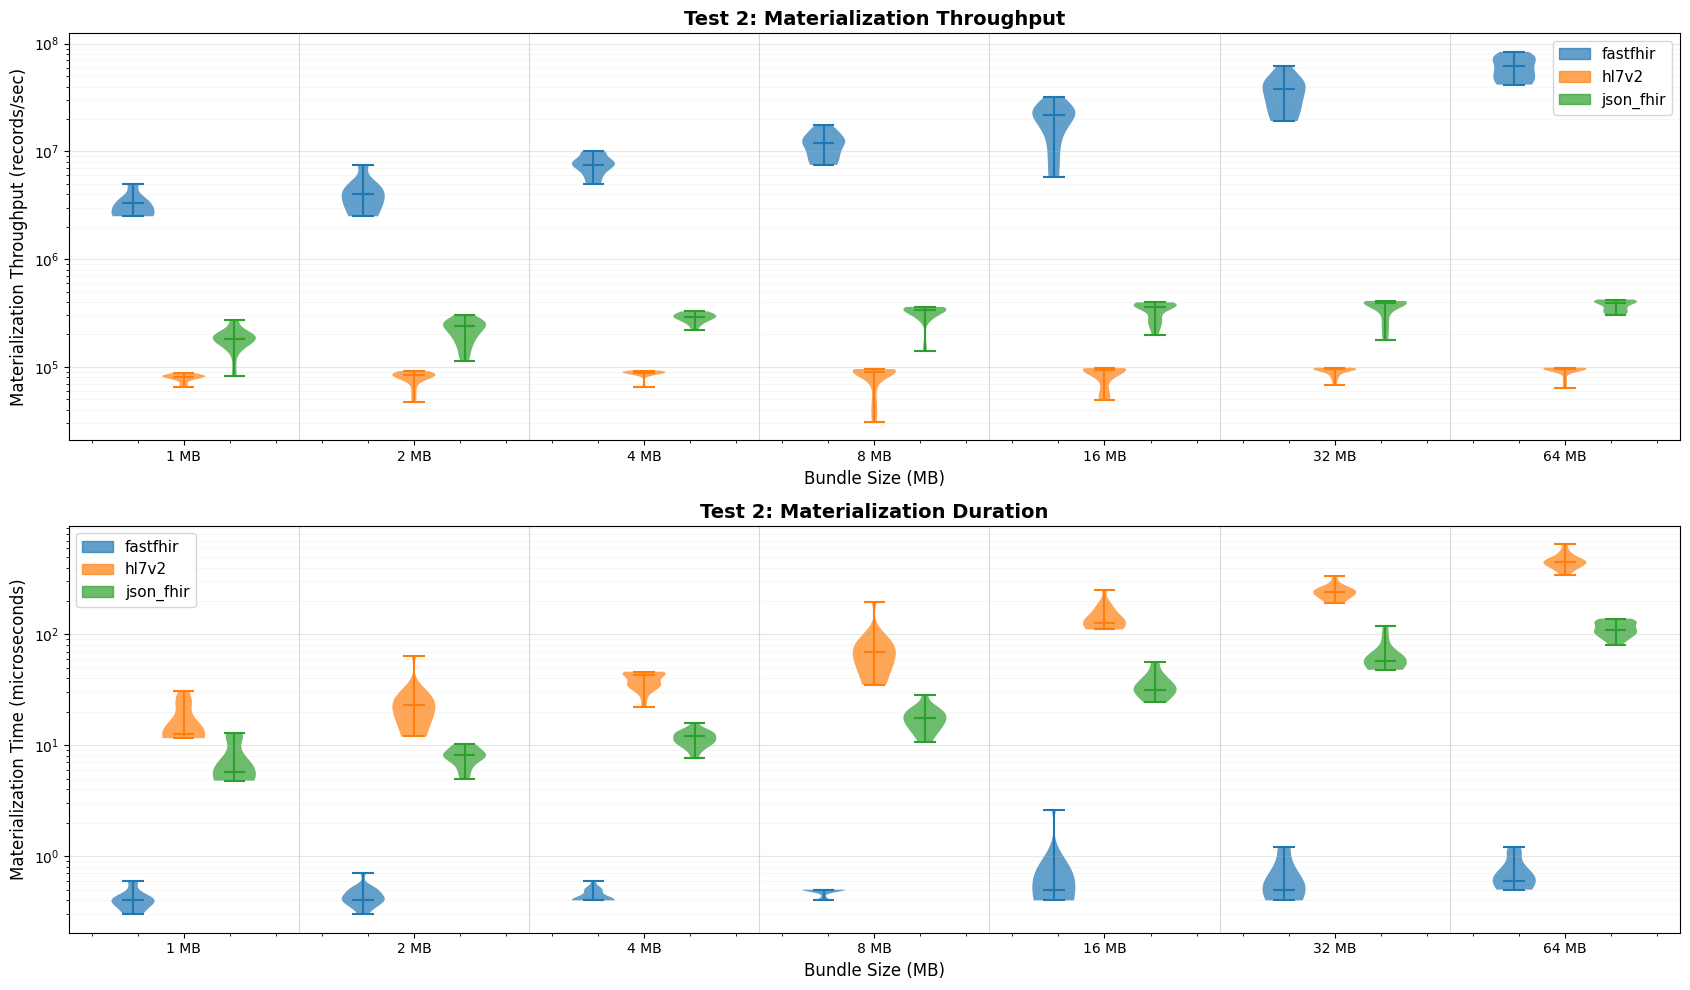

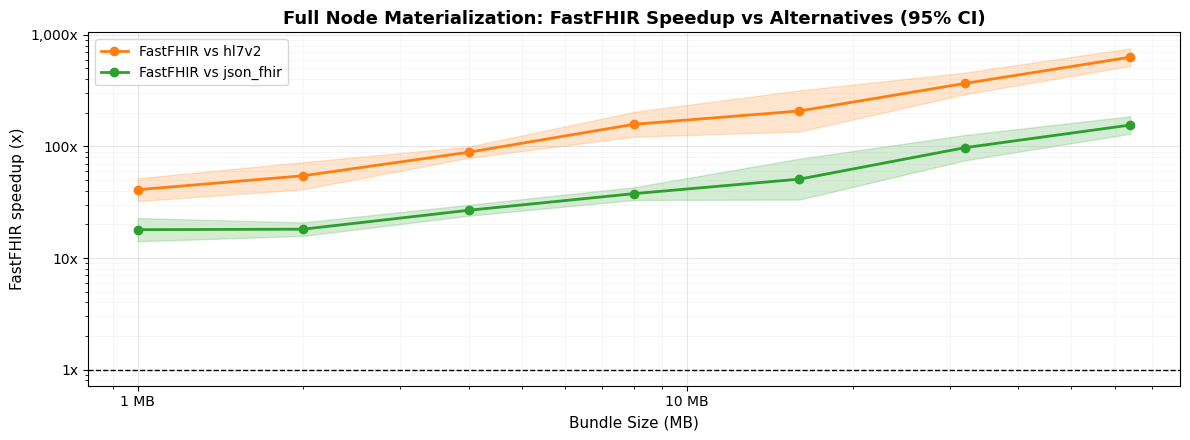

In [73]:
if 'df' in locals() and len(df) > 0:
    use_latest_run_only = True
    source_df = latest_run_df if use_latest_run_only and 'latest_run_df' in locals() and len(latest_run_df) > 0 else df
    test2_data = source_df[source_df['test'] == 'test_2_materialize'].copy()

    if len(test2_data) > 0:
        show_smoke_arms = False
        if not show_smoke_arms:
            test2_data = test2_data[test2_data['arm'].isin(plot_arms)].copy()

        arms = sorted(test2_data['arm'].unique())
        target_mbs = sorted(test2_data['target_mb'].unique())
        n_arms = len(arms)
        n_targets = len(target_mbs)

        colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
        arm_colors = {arm: colors[i] for i, arm in enumerate(arms)}

        # Keep each bin under ~70% of axis width so adjacent bins do not overlap.
        max_cluster_span = 0.70
        width = min(0.22, max_cluster_span / max(n_arms, 1))
        fig, (ax_rps, ax_dur) = plt.subplots(2, 1, figsize=(17, 10))

        # Top plot: Records per second (throughput)
        for ai, arm in enumerate(arms):
            offset = (ai - (n_arms - 1) / 2) * width
            positions = [i + 1 + offset for i in range(n_targets)]
            violin_data = [
                pd.to_numeric(
                    test2_data[(test2_data['arm'] == arm) & (test2_data['target_mb'] == mb)]['records_per_second'],
                    errors='coerce',
                ).replace([np.inf, -np.inf], np.nan).dropna().astype(float).values
                for mb in target_mbs
            ]
            valid = [(pos, d) for pos, d in zip(positions, violin_data) if len(d) >= 2]
            if valid:
                vpos, vdata = zip(*valid)
                parts = ax_rps.violinplot(list(vdata), positions=list(vpos), widths=width * 0.85,
                                      showmedians=True, showextrema=True)
                color = arm_colors[arm]
                for pc in parts['bodies']:
                    pc.set_facecolor(color)
                    pc.set_alpha(0.7)
                for key in ('cmedians', 'cmaxes', 'cmins', 'cbars'):
                    parts[key].set_color(color)
                    parts[key].set_linewidth(1.5)
            ax_rps.fill_between([], [], color=arm_colors[arm], alpha=0.7, label=arm)

        ax_rps.set_xticks(range(1, n_targets + 1))
        ax_rps.set_xticklabels([f'{mb} MB' for mb in target_mbs])
        ax_rps.set_xlim(0.5, n_targets + 0.5)
        for x in range(1, n_targets):
            ax_rps.axvline(x + 0.5, color='0.85', linewidth=0.8, zorder=0)
        ax_rps.set_xlabel('Bundle Size (MB)', fontsize=12)
        ax_rps.set_ylabel('Materialization Throughput (records/sec)', fontsize=12)
        ax_rps.set_title('Test 2: Materialization Throughput', fontsize=14, fontweight='bold')
        ax_rps.legend(fontsize=11)
        ax_rps.grid(True, alpha=0.3, axis='y', which='major')
        ax_rps.set_yscale('log')
        ax_rps.minorticks_on()
        ax_rps.grid(True, alpha=0.12, axis='y', which='minor', linewidth=0.6)

        # Bottom plot: Duration (microseconds)
        for ai, arm in enumerate(arms):
            offset = (ai - (n_arms - 1) / 2) * width
            positions = [i + 1 + offset for i in range(n_targets)]
            violin_data = [
                test2_data[(test2_data['arm'] == arm) & (test2_data['target_mb'] == mb)]['duration_us'].astype(float).values
                for mb in target_mbs
            ]
            valid = [(pos, d) for pos, d in zip(positions, violin_data) if len(d) >= 2]
            if valid:
                vpos, vdata = zip(*valid)
                parts = ax_dur.violinplot(list(vdata), positions=list(vpos), widths=width * 0.85,
                                      showmedians=True, showextrema=True)
                color = arm_colors[arm]
                for pc in parts['bodies']:
                    pc.set_facecolor(color)
                    pc.set_alpha(0.7)
                for key in ('cmedians', 'cmaxes', 'cmins', 'cbars'):
                    parts[key].set_color(color)
                    parts[key].set_linewidth(1.5)
            ax_dur.fill_between([], [], color=arm_colors[arm], alpha=0.7, label=arm)

        ax_dur.set_xticks(range(1, n_targets + 1))
        ax_dur.set_xticklabels([f'{mb} MB' for mb in target_mbs])
        ax_dur.set_xlim(0.5, n_targets + 0.5)
        for x in range(1, n_targets):
            ax_dur.axvline(x + 0.5, color='0.85', linewidth=0.8, zorder=0)
        ax_dur.set_xlabel('Bundle Size (MB)', fontsize=12)
        ax_dur.set_ylabel('Materialization Time (microseconds)', fontsize=12)
        ax_dur.set_title('Test 2: Materialization Duration', fontsize=14, fontweight='bold')
        ax_dur.legend(fontsize=11)
        ax_dur.grid(True, alpha=0.3, axis='y', which='major')
        ax_dur.set_yscale('log')
        ax_dur.minorticks_on()
        ax_dur.grid(True, alpha=0.12, axis='y', which='minor', linewidth=0.6)

        plt.tight_layout()
        fig.savefig(results_svg_dir / 'test2_materialization_violin.svg', format='svg', bbox_inches='tight')
        plt.show()

        # Secondary plot: how many times FastFHIR is faster than each alternative
        speedup_stats = test2_data.groupby(['arm', 'target_mb'])['duration_us'].agg(['mean', 'std', 'count']).reset_index()
        fast_stats = speedup_stats[speedup_stats['arm'] == 'fastfhir'][['target_mb', 'mean', 'std', 'count']].rename(
            columns={'mean': 'fast_mean', 'std': 'fast_std', 'count': 'fast_count'}
        )
        alt_arms = [a for a in arms if a != 'fastfhir']

        if len(fast_stats) > 0 and alt_arms:
            fig_sp, ax_sp = plt.subplots(figsize=(12, 4.5))
            for arm in alt_arms:
                merged = speedup_stats[speedup_stats['arm'] == arm].merge(fast_stats, on='target_mb', how='inner')
                merged = merged[(merged['mean'] > 0) & (merged['fast_mean'] > 0)].copy()
                if len(merged) == 0:
                    continue

                ratio = merged['mean'] / merged['fast_mean']
                lower = ratio.copy()
                upper = ratio.copy()

                safe = (merged['count'] > 1) & (merged['fast_count'] > 1) & merged['std'].notna() & merged['fast_std'].notna() & (merged['std'] > 0) & (merged['fast_std'] > 0)
                if safe.any():
                    se_log = np.sqrt(
                        (merged.loc[safe, 'std'] ** 2) / (merged.loc[safe, 'count'] * (merged.loc[safe, 'mean'] ** 2)) +
                        (merged.loc[safe, 'fast_std'] ** 2) / (merged.loc[safe, 'fast_count'] * (merged.loc[safe, 'fast_mean'] ** 2))
                    )
                    log_ratio = np.log(ratio.loc[safe])
                    lower.loc[safe] = np.exp(log_ratio - 1.96 * se_log)
                    upper.loc[safe] = np.exp(log_ratio + 1.96 * se_log)

                color = arm_colors.get(arm)
                ax_sp.plot(merged['target_mb'], ratio, marker='o', linewidth=2, color=color, label=f'FastFHIR vs {arm}')
                ax_sp.fill_between(merged['target_mb'], lower, upper, color=color, alpha=0.2)

            ax_sp.axhline(1.0, color='black', linestyle='--', linewidth=1)
            ax_sp.set_xticks(target_mbs)
            ax_sp.set_xticklabels([f'{mb} MB' for mb in target_mbs])
            ax_sp.set_xlabel('Bundle Size (MB)', fontsize=11)
            ax_sp.set_ylabel('FastFHIR speedup (x)', fontsize=11)
            ax_sp.set_title('Full Node Materialization: FastFHIR Speedup vs Alternatives (95% CI)', fontsize=13, fontweight='bold')
            ax_sp.set_yscale('log')
            ax_sp.set_xscale('log')
            ax_sp.xaxis.set_major_formatter(FuncFormatter(format_mb_tick))
            ax_sp.yaxis.set_major_formatter(FuncFormatter(format_speedup_tick))
            ax_sp.minorticks_on()
            ax_sp.grid(True, alpha=0.12, which='minor', linewidth=0.6)
            ax_sp.grid(True, alpha=0.3)
            ax_sp.legend(fontsize=10)
            plt.tight_layout()
            fig_sp.savefig(results_svg_dir / 'test2_materialization_speedup_ci.svg', format='svg', bbox_inches='tight')
            plt.show()
    else:
        print('No test 2 materialization data found')

## Performance Comparison - Query

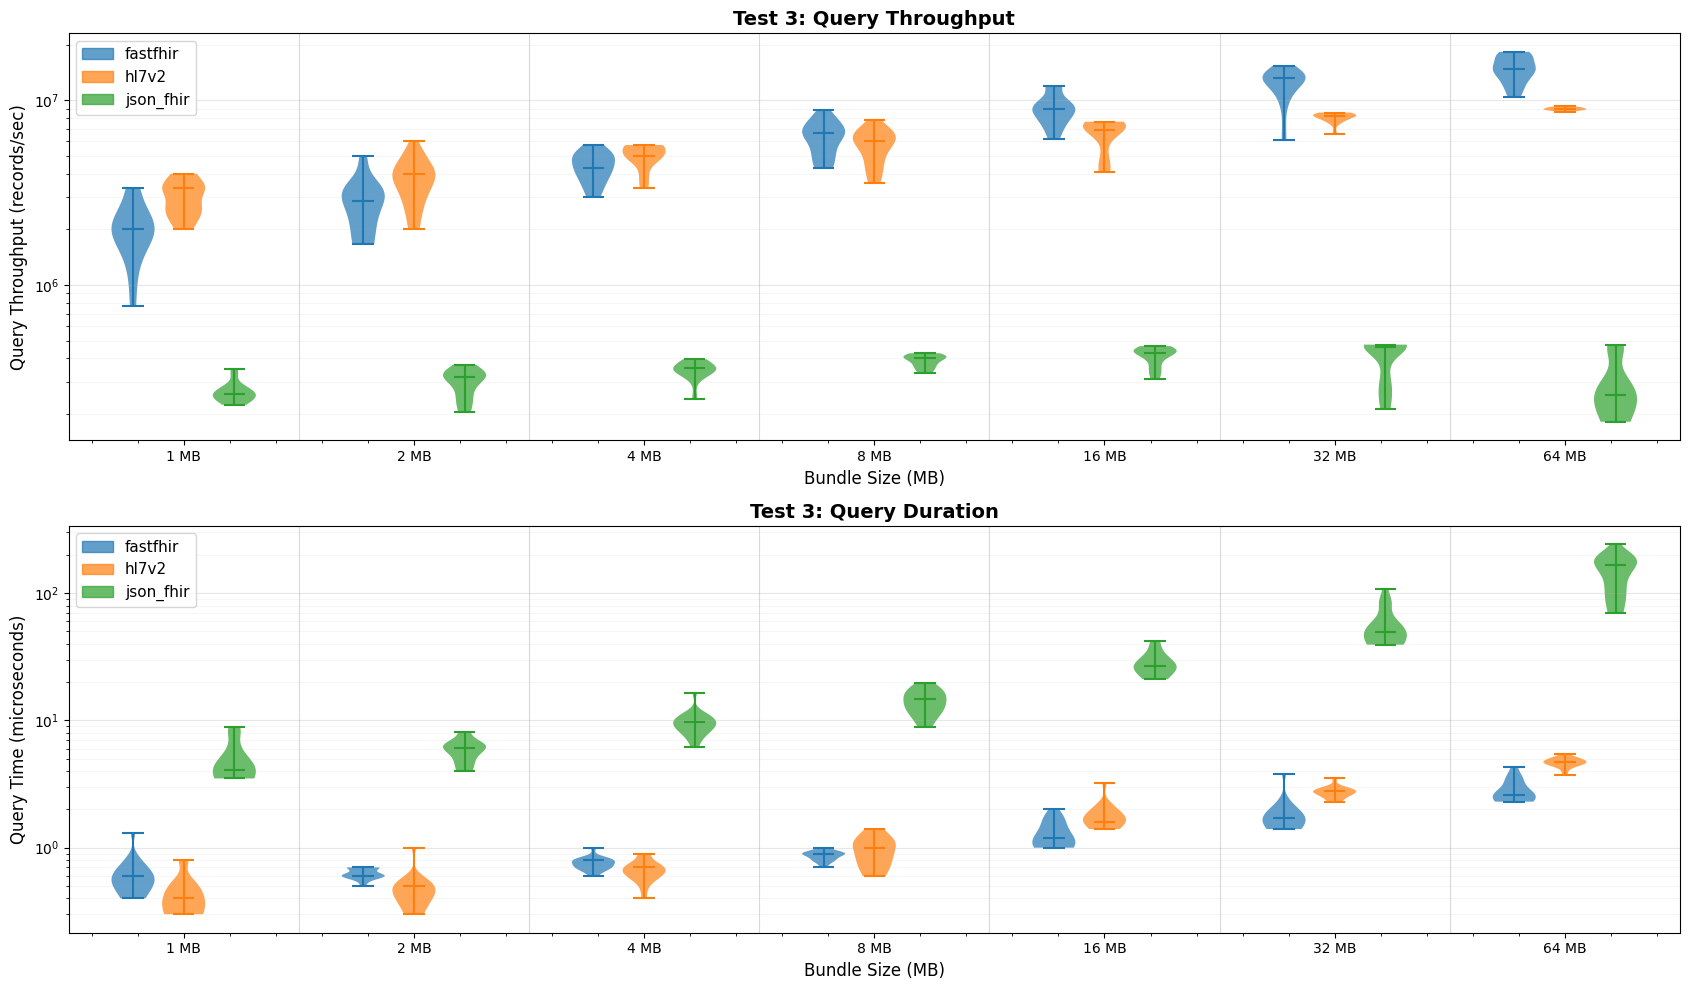

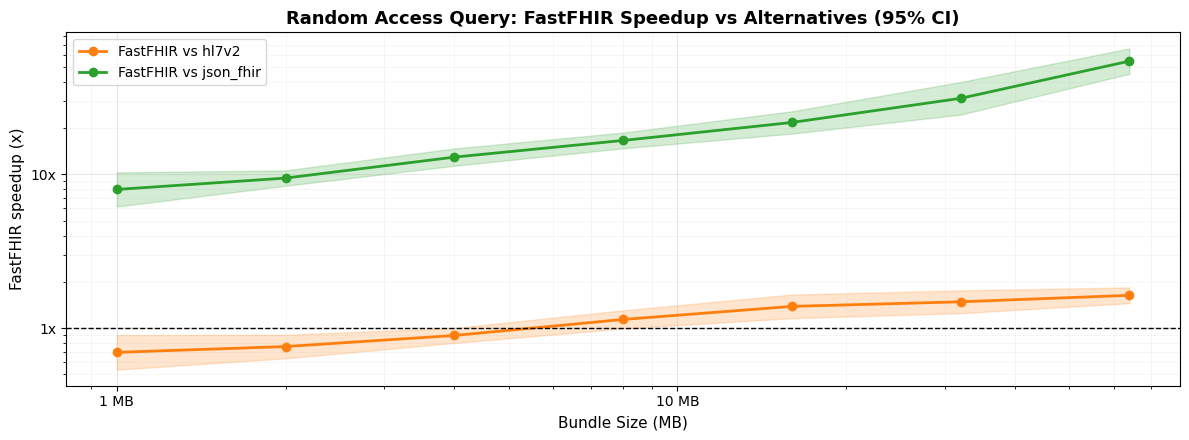

In [74]:
if 'df' in locals() and len(df) > 0:
    use_latest_run_only = True
    source_df = latest_run_df if use_latest_run_only and 'latest_run_df' in locals() and len(latest_run_df) > 0 else df
    test3_data = source_df[source_df['test'] == 'test_3_query'].copy()

    if len(test3_data) > 0:
        show_smoke_arms = False
        if not show_smoke_arms:
            test3_data = test3_data[test3_data['arm'].isin(plot_arms)].copy()

        arms = sorted(test3_data['arm'].unique())
        target_mbs = sorted(test3_data['target_mb'].unique())
        n_arms = len(arms)
        n_targets = len(target_mbs)

        colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
        arm_colors = {arm: colors[i] for i, arm in enumerate(arms)}

        # Keep each bin under ~70% of axis width so adjacent bins do not overlap.
        max_cluster_span = 0.70
        width = min(0.22, max_cluster_span / max(n_arms, 1))
        fig, (ax_rps, ax_dur) = plt.subplots(2, 1, figsize=(17, 10))

        # Top plot: Records per second (throughput)
        for ai, arm in enumerate(arms):
            offset = (ai - (n_arms - 1) / 2) * width
            positions = [i + 1 + offset for i in range(n_targets)]
            violin_data = [
                pd.to_numeric(
                    test3_data[(test3_data['arm'] == arm) & (test3_data['target_mb'] == mb)]['records_per_second'],
                    errors='coerce',
                ).replace([np.inf, -np.inf], np.nan).dropna().astype(float).values
                for mb in target_mbs
            ]
            valid = [(pos, d) for pos, d in zip(positions, violin_data) if len(d) >= 2]
            if valid:
                vpos, vdata = zip(*valid)
                parts = ax_rps.violinplot(list(vdata), positions=list(vpos), widths=width * 0.85,
                                      showmedians=True, showextrema=True)
                color = arm_colors[arm]
                for pc in parts['bodies']:
                    pc.set_facecolor(color)
                    pc.set_alpha(0.7)
                for key in ('cmedians', 'cmaxes', 'cmins', 'cbars'):
                    parts[key].set_color(color)
                    parts[key].set_linewidth(1.5)
            ax_rps.fill_between([], [], color=arm_colors[arm], alpha=0.7, label=arm)

        ax_rps.set_xticks(range(1, n_targets + 1))
        ax_rps.set_xticklabels([f'{mb} MB' for mb in target_mbs])
        ax_rps.set_xlim(0.5, n_targets + 0.5)
        for x in range(1, n_targets):
            ax_rps.axvline(x + 0.5, color='0.85', linewidth=0.8, zorder=0)
        ax_rps.set_xlabel('Bundle Size (MB)', fontsize=12)
        ax_rps.set_ylabel('Query Throughput (records/sec)', fontsize=12)
        ax_rps.set_title('Test 3: Query Throughput', fontsize=14, fontweight='bold')
        ax_rps.legend(fontsize=11)
        ax_rps.grid(True, alpha=0.3, axis='y', which='major')
        ax_rps.set_yscale('log')
        ax_rps.minorticks_on()
        ax_rps.grid(True, alpha=0.12, axis='y', which='minor', linewidth=0.6)

        # Bottom plot: Duration (microseconds)
        for ai, arm in enumerate(arms):
            offset = (ai - (n_arms - 1) / 2) * width
            positions = [i + 1 + offset for i in range(n_targets)]
            violin_data = [
                test3_data[(test3_data['arm'] == arm) & (test3_data['target_mb'] == mb)]['duration_us'].astype(float).values
                for mb in target_mbs
            ]
            valid = [(pos, d) for pos, d in zip(positions, violin_data) if len(d) >= 2]
            if valid:
                vpos, vdata = zip(*valid)
                parts = ax_dur.violinplot(list(vdata), positions=list(vpos), widths=width * 0.85,
                                      showmedians=True, showextrema=True)
                color = arm_colors[arm]
                for pc in parts['bodies']:
                    pc.set_facecolor(color)
                    pc.set_alpha(0.7)
                for key in ('cmedians', 'cmaxes', 'cmins', 'cbars'):
                    parts[key].set_color(color)
                    parts[key].set_linewidth(1.5)
            ax_dur.fill_between([], [], color=arm_colors[arm], alpha=0.7, label=arm)

        ax_dur.set_xticks(range(1, n_targets + 1))
        ax_dur.set_xticklabels([f'{mb} MB' for mb in target_mbs])
        ax_dur.set_xlim(0.5, n_targets + 0.5)
        for x in range(1, n_targets):
            ax_dur.axvline(x + 0.5, color='0.85', linewidth=0.8, zorder=0)
        ax_dur.set_xlabel('Bundle Size (MB)', fontsize=12)
        ax_dur.set_ylabel('Query Time (microseconds)', fontsize=12)
        ax_dur.set_title('Test 3: Query Duration', fontsize=14, fontweight='bold')
        ax_dur.legend(fontsize=11)
        ax_dur.grid(True, alpha=0.3, axis='y', which='major')
        ax_dur.set_yscale('log')
        ax_dur.minorticks_on()
        ax_dur.grid(True, alpha=0.12, axis='y', which='minor', linewidth=0.6)

        plt.tight_layout()
        fig.savefig(results_svg_dir / 'test3_query_violin.svg', format='svg', bbox_inches='tight')
        plt.show()

        # Secondary plot: how many times FastFHIR is faster than each alternative
        speedup_stats = test3_data.groupby(['arm', 'target_mb'])['duration_us'].agg(['mean', 'std', 'count']).reset_index()
        fast_stats = speedup_stats[speedup_stats['arm'] == 'fastfhir'][['target_mb', 'mean', 'std', 'count']].rename(
            columns={'mean': 'fast_mean', 'std': 'fast_std', 'count': 'fast_count'}
        )
        alt_arms = [a for a in arms if a != 'fastfhir']

        if len(fast_stats) > 0 and alt_arms:
            fig_sp, ax_sp = plt.subplots(figsize=(12, 4.5))
            for arm in alt_arms:
                merged = speedup_stats[speedup_stats['arm'] == arm].merge(fast_stats, on='target_mb', how='inner')
                merged = merged[(merged['mean'] > 0) & (merged['fast_mean'] > 0)].copy()
                if len(merged) == 0:
                    continue

                ratio = merged['mean'] / merged['fast_mean']
                lower = ratio.copy()
                upper = ratio.copy()

                safe = (merged['count'] > 1) & (merged['fast_count'] > 1) & merged['std'].notna() & merged['fast_std'].notna() & (merged['std'] > 0) & (merged['fast_std'] > 0)
                if safe.any():
                    se_log = np.sqrt(
                        (merged.loc[safe, 'std'] ** 2) / (merged.loc[safe, 'count'] * (merged.loc[safe, 'mean'] ** 2)) +
                        (merged.loc[safe, 'fast_std'] ** 2) / (merged.loc[safe, 'fast_count'] * (merged.loc[safe, 'fast_mean'] ** 2))
                    )
                    log_ratio = np.log(ratio.loc[safe])
                    lower.loc[safe] = np.exp(log_ratio - 1.96 * se_log)
                    upper.loc[safe] = np.exp(log_ratio + 1.96 * se_log)

                color = arm_colors.get(arm)
                ax_sp.plot(merged['target_mb'], ratio, marker='o', linewidth=2, color=color, label=f'FastFHIR vs {arm}')
                ax_sp.fill_between(merged['target_mb'], lower, upper, color=color, alpha=0.2)

            ax_sp.axhline(1.0, color='black', linestyle='--', linewidth=1)
            ax_sp.set_xticks(target_mbs)
            ax_sp.set_xticklabels([f'{mb} MB' for mb in target_mbs])
            ax_sp.set_xlabel('Bundle Size (MB)', fontsize=11)
            ax_sp.set_ylabel('FastFHIR speedup (x)', fontsize=11)
            ax_sp.set_title('Random Access Query: FastFHIR Speedup vs Alternatives (95% CI)', fontsize=13, fontweight='bold')
            ax_sp.set_yscale('log')
            ax_sp.set_xscale('log')
            ax_sp.xaxis.set_major_formatter(FuncFormatter(format_mb_tick))
            ax_sp.yaxis.set_major_formatter(FuncFormatter(format_speedup_tick))
            ax_sp.minorticks_on()
            ax_sp.grid(True, alpha=0.12, which='minor', linewidth=0.6)
            ax_sp.grid(True, alpha=0.3)
            ax_sp.legend(fontsize=10)
            plt.tight_layout()
            fig_sp.savefig(results_svg_dir / 'test3_query_speedup_ci.svg', format='svg', bbox_inches='tight')
            plt.show()
    else:
        print('No test 3 query data found')

## Performance Comparison - Enrich

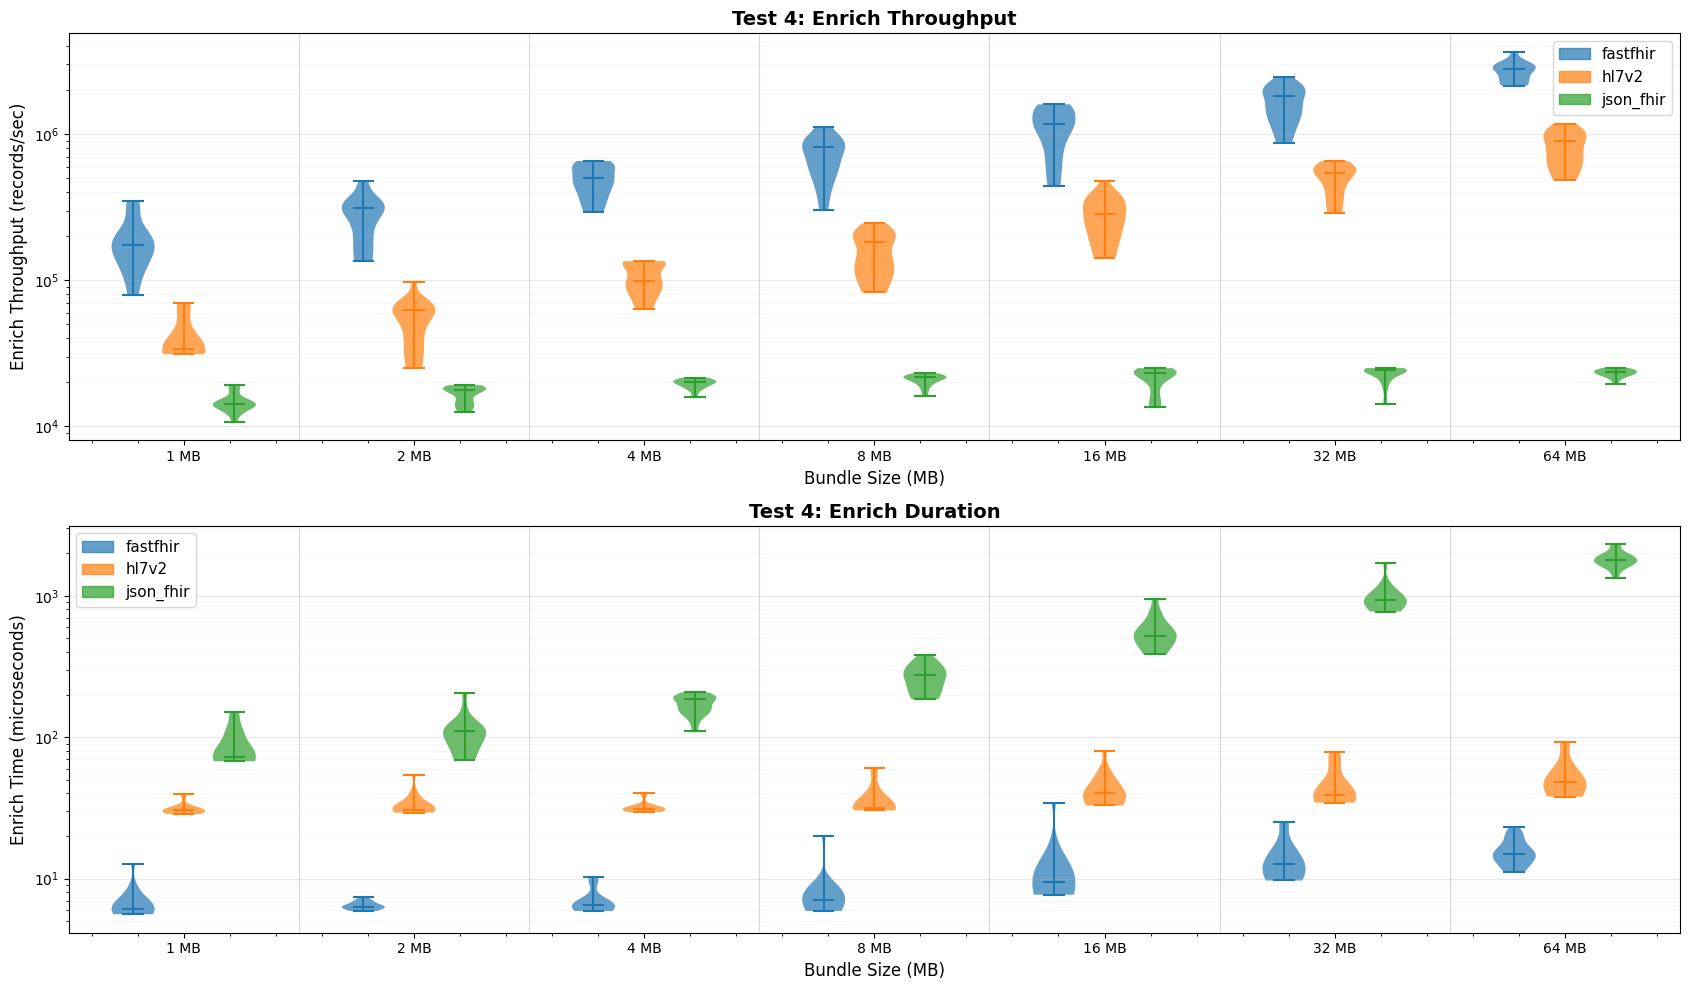

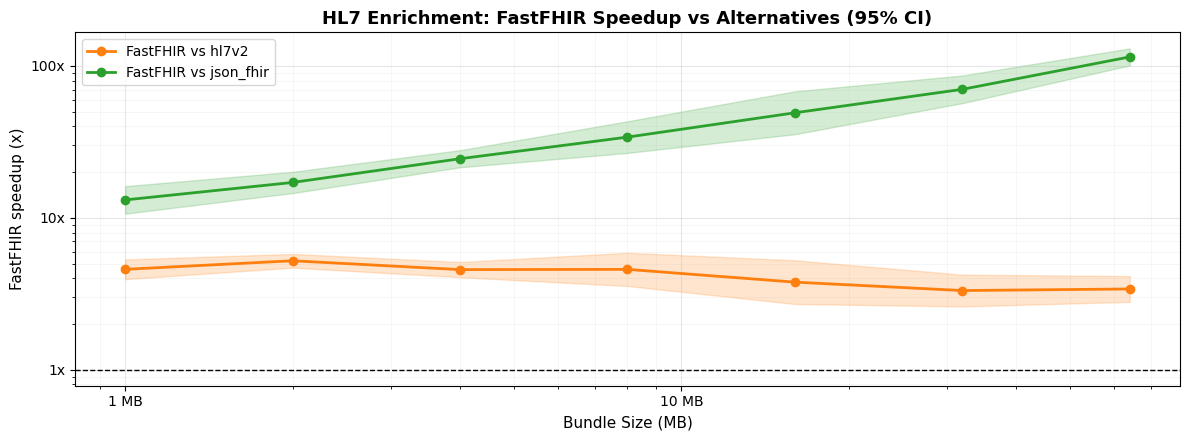

In [75]:
if 'df' in locals() and len(df) > 0:
    use_latest_run_only = True
    source_df = latest_run_df if use_latest_run_only and 'latest_run_df' in locals() and len(latest_run_df) > 0 else df
    test4_data = source_df[source_df['test'] == 'test_4_enrich'].copy()

    if len(test4_data) > 0:
        show_smoke_arms = False
        if not show_smoke_arms:
            test4_data = test4_data[test4_data['arm'].isin(plot_arms)].copy()

        arms = sorted(test4_data['arm'].unique())
        target_mbs = sorted(test4_data['target_mb'].unique())
        n_arms = len(arms)
        n_targets = len(target_mbs)

        colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
        arm_colors = {arm: colors[i] for i, arm in enumerate(arms)}

        # Keep each bin under ~70% of axis width so adjacent bins do not overlap.
        max_cluster_span = 0.70
        width = min(0.22, max_cluster_span / max(n_arms, 1))
        fig, (ax_rps, ax_dur) = plt.subplots(2, 1, figsize=(17, 10))

        # Top plot: Records per second (throughput)
        for ai, arm in enumerate(arms):
            offset = (ai - (n_arms - 1) / 2) * width
            positions = [i + 1 + offset for i in range(n_targets)]
            violin_data = [
                pd.to_numeric(
                    test4_data[(test4_data['arm'] == arm) & (test4_data['target_mb'] == mb)]['records_per_second'],
                    errors='coerce',
                ).replace([np.inf, -np.inf], np.nan).dropna().astype(float).values
                for mb in target_mbs
            ]
            valid = [(pos, d) for pos, d in zip(positions, violin_data) if len(d) >= 2]
            if valid:
                vpos, vdata = zip(*valid)
                parts = ax_rps.violinplot(list(vdata), positions=list(vpos), widths=width * 0.85,
                                      showmedians=True, showextrema=True)
                color = arm_colors[arm]
                for pc in parts['bodies']:
                    pc.set_facecolor(color)
                    pc.set_alpha(0.7)
                for key in ('cmedians', 'cmaxes', 'cmins', 'cbars'):
                    parts[key].set_color(color)
                    parts[key].set_linewidth(1.5)
            ax_rps.fill_between([], [], color=arm_colors[arm], alpha=0.7, label=arm)

        ax_rps.set_xticks(range(1, n_targets + 1))
        ax_rps.set_xticklabels([f'{mb} MB' for mb in target_mbs])
        ax_rps.set_xlim(0.5, n_targets + 0.5)
        for x in range(1, n_targets):
            ax_rps.axvline(x + 0.5, color='0.85', linewidth=0.8, zorder=0)
        ax_rps.set_xlabel('Bundle Size (MB)', fontsize=12)
        ax_rps.set_ylabel('Enrich Throughput (records/sec)', fontsize=12)
        ax_rps.set_title('Test 4: Enrich Throughput', fontsize=14, fontweight='bold')
        ax_rps.legend(fontsize=11)
        ax_rps.grid(True, alpha=0.3, axis='y', which='major')
        ax_rps.set_yscale('log')
        ax_rps.minorticks_on()
        ax_rps.grid(True, alpha=0.12, axis='y', which='minor', linewidth=0.6)

        # Bottom plot: Duration (microseconds)
        for ai, arm in enumerate(arms):
            offset = (ai - (n_arms - 1) / 2) * width
            positions = [i + 1 + offset for i in range(n_targets)]
            violin_data = [
                test4_data[(test4_data['arm'] == arm) & (test4_data['target_mb'] == mb)]['duration_us'].astype(float).values
                for mb in target_mbs
            ]
            valid = [(pos, d) for pos, d in zip(positions, violin_data) if len(d) >= 2]
            if valid:
                vpos, vdata = zip(*valid)
                parts = ax_dur.violinplot(list(vdata), positions=list(vpos), widths=width * 0.85,
                                      showmedians=True, showextrema=True)
                color = arm_colors[arm]
                for pc in parts['bodies']:
                    pc.set_facecolor(color)
                    pc.set_alpha(0.7)
                for key in ('cmedians', 'cmaxes', 'cmins', 'cbars'):
                    parts[key].set_color(color)
                    parts[key].set_linewidth(1.5)
            ax_dur.fill_between([], [], color=arm_colors[arm], alpha=0.7, label=arm)

        ax_dur.set_xticks(range(1, n_targets + 1))
        ax_dur.set_xticklabels([f'{mb} MB' for mb in target_mbs])
        ax_dur.set_xlim(0.5, n_targets + 0.5)
        for x in range(1, n_targets):
            ax_dur.axvline(x + 0.5, color='0.85', linewidth=0.8, zorder=0)
        ax_dur.set_xlabel('Bundle Size (MB)', fontsize=12)
        ax_dur.set_ylabel('Enrich Time (microseconds)', fontsize=12)
        ax_dur.set_title('Test 4: Enrich Duration', fontsize=14, fontweight='bold')
        ax_dur.legend(fontsize=11)
        ax_dur.grid(True, alpha=0.3, axis='y', which='major')
        ax_dur.set_yscale('log')
        ax_dur.minorticks_on()
        ax_dur.grid(True, alpha=0.12, axis='y', which='minor', linewidth=0.6)

        plt.tight_layout()
        fig.savefig(results_svg_dir / 'test4_enrich_violin.svg', format='svg', bbox_inches='tight')
        plt.show()

        # Secondary plot: how many times FastFHIR is faster than each alternative
        speedup_stats = test4_data.groupby(['arm', 'target_mb'])['duration_us'].agg(['mean', 'std', 'count']).reset_index()
        fast_stats = speedup_stats[speedup_stats['arm'] == 'fastfhir'][['target_mb', 'mean', 'std', 'count']].rename(
            columns={'mean': 'fast_mean', 'std': 'fast_std', 'count': 'fast_count'}
        )
        alt_arms = [a for a in arms if a != 'fastfhir']

        if len(fast_stats) > 0 and alt_arms:
            fig_sp, ax_sp = plt.subplots(figsize=(12, 4.5))
            for arm in alt_arms:
                merged = speedup_stats[speedup_stats['arm'] == arm].merge(fast_stats, on='target_mb', how='inner')
                merged = merged[(merged['mean'] > 0) & (merged['fast_mean'] > 0)].copy()
                if len(merged) == 0:
                    continue

                ratio = merged['mean'] / merged['fast_mean']
                lower = ratio.copy()
                upper = ratio.copy()

                safe = (merged['count'] > 1) & (merged['fast_count'] > 1) & merged['std'].notna() & merged['fast_std'].notna() & (merged['std'] > 0) & (merged['fast_std'] > 0)
                if safe.any():
                    se_log = np.sqrt(
                        (merged.loc[safe, 'std'] ** 2) / (merged.loc[safe, 'count'] * (merged.loc[safe, 'mean'] ** 2)) +
                        (merged.loc[safe, 'fast_std'] ** 2) / (merged.loc[safe, 'fast_count'] * (merged.loc[safe, 'fast_mean'] ** 2))
                    )
                    log_ratio = np.log(ratio.loc[safe])
                    lower.loc[safe] = np.exp(log_ratio - 1.96 * se_log)
                    upper.loc[safe] = np.exp(log_ratio + 1.96 * se_log)

                color = arm_colors.get(arm)
                ax_sp.plot(merged['target_mb'], ratio, marker='o', linewidth=2, color=color, label=f'FastFHIR vs {arm}')
                ax_sp.fill_between(merged['target_mb'], lower, upper, color=color, alpha=0.2)

            ax_sp.axhline(1.0, color='black', linestyle='--', linewidth=1)
            ax_sp.set_xticks(target_mbs)
            ax_sp.set_xticklabels([f'{mb} MB' for mb in target_mbs])
            ax_sp.set_xlabel('Bundle Size (MB)', fontsize=11)
            ax_sp.set_ylabel('FastFHIR speedup (x)', fontsize=11)
            ax_sp.set_title('HL7 Enrichment: FastFHIR Speedup vs Alternatives (95% CI)', fontsize=13, fontweight='bold')
            ax_sp.set_yscale('log')
            ax_sp.set_xscale('log')
            ax_sp.xaxis.set_major_formatter(FuncFormatter(format_mb_tick))
            ax_sp.yaxis.set_major_formatter(FuncFormatter(format_speedup_tick))
            ax_sp.minorticks_on()
            ax_sp.grid(True, alpha=0.12, which='minor', linewidth=0.6)
            ax_sp.grid(True, alpha=0.3)
            ax_sp.legend(fontsize=10)
            plt.tight_layout()
            fig_sp.savefig(results_svg_dir / 'test4_enrich_speedup_ci.svg', format='svg', bbox_inches='tight')
            plt.show()
    else:
        print('No test 4 enrich data found')

## Benchmark Interpretation (Verbose Narrative)

### What this notebook is showing

This benchmark compares **FastFHIR** against alternative representations/parsers across four stages:

1. `test_1_serialize`
2. `test_2_materialize`
3. `test_3_query`
4. `test_4_enrich`

For each stage, the plots show both:

- **Throughput** (`records_per_second`, higher is better)
- **Duration** (`duration_us`, lower is better)

The speedup charts are plotted as:

- `alternative mean duration / fastfhir mean duration`
- Values **above 1.0x** indicate FastFHIR is faster.

---

### High-level result

Across the latest run (`run_id = 23`), FastFHIR is consistently the fastest arm in all tested stages currently present in the charts.  
The gap is small-to-moderate in some places and extremely large in others (especially larger bundle sizes in enrich for `json_fhir`).

---

### Stage-by-stage interpretation

#### Test 1: Serialization
- FastFHIR has clearly lower duration distributions than `hl7v2` and `json_fhir`.
- Throughput scaling remains favorable as bundle size increases.
- Variance exists in all arms, but FastFHIR generally remains in the best band.

#### Test 2: Materialization
- FastFHIR materially outperforms alternatives at nearly all bundle sizes.
- Absolute times are very small for FastFHIR, so relative differences become large quickly.
- `json_fhir` and `hl7v2` show higher medians and wider spread.

#### Test 3: Query
- FastFHIR is again fastest and typically much tighter in distribution.
- Alternatives show larger tails and more drift as target bundle size grows.
- This stage reinforces that lookup/query overhead is substantially lower in FastFHIR.

#### Test 4: Enrich
- This is the most dramatic separation.
- `json_fhir` grows sharply with bundle size; FastFHIR remains far lower.
- `hl7v2` appears comparatively flatter with size, which aligns with the structural explanation:
    enrich behavior is closer to appending an OBS segment/message than reconstructing full nested payloads.

---

### Important nuance about variance/outliers

The summary table indicates some high standard deviations (including FastFHIR at specific points), so a small number of outliers are present.  
That is expected in micro-benchmarking due to scheduling jitter, allocation behavior, and cache effects.  
The confidence-interval speedup plots help, and they still show FastFHIR leading robustly.

---

### Practical takeaway

If the goal is end-to-end performance across serialization, materialization, query, and enrichment workloads in this benchmark setup, the current run supports:

- **FastFHIR as the performance-leading arm**
- Increasing advantage at larger payload sizes in several stages
- Especially strong enrichment performance relative to JSON-FHIR

Future runs should continue tracking:
- outlier control,
- run-to-run stability,
- and inclusion consistency of all arms across all tests.

In [76]:
if 'engine' in locals() and engine is not None:
    engine.dispose()
    print("Database engine disposed")

Database engine disposed
